In [1]:
from google.colab import files

uploaded = files.upload()

Saving IT_Job_Roles_Skills.csv to IT_Job_Roles_Skills.csv


In [2]:
import pandas as pd

df = pd.read_csv("IT_Job_Roles_Skills.csv", encoding="latin1")

In [3]:
df.head()

,Job Title,Job Description,Skills,Certifications
0,Admin Big Data,Responsible for managing and overseeing big da...,"Hadoop, Spark, MapReduce, Data Lakes, Data War...","Cloudera Certified Professional (CCP), Hortonw..."
1,Ansible Operations Engineer,Focuses on automating IT processes using Ansib...,"Ansible, Linux, Automation, Cloud Platforms, C...",Red Hat Certified Specialist in Ansible Automa...
2,Artifactory Administrator,Manages the Artifactory repository for build a...,"Artifactory, CI/CD, Jenkins, Docker, Maven, Gr...","JFrog Artifactory Certification, DevOps Instit..."
3,Artificial Intelligence / Machine Learning Leader,"Leads AI/ML projects and teams, defining strat...","AI Strategy, Machine Learning, Team Management...","AI-900: Microsoft Azure AI Fundamentals, Certi..."
4,Artificial Intelligence / Machine Learning Sr....,Senior role overseeing multiple AI/ML initiati...,"AI Strategy, Machine Learning, Team Management...",Certified Artificial Intelligence Practitioner...


In [4]:
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns)

Shape: (493, 4)

Columns:
Index(['Job Title', 'Job Description', 'Skills', 'Certifications'], dtype='object')


In [5]:
df.isnull().sum()

,0
Job Title,0
Job Description,0
Skills,0
Certifications,0


In [6]:
df.columns

Index(['Job Title', 'Job Description', 'Skills', 'Certifications'], dtype='object')

In [7]:
df["Job Title"].head(20).tolist()

['Admin Big Data',
 'Ansible Operations Engineer',
 'Artifactory Administrator',
 'Artificial Intelligence / Machine Learning Leader',
 'Artificial Intelligence / Machine Learning Sr.Leader',
 'Artificial intelligence Architect',
 'Artificial Intelligence Researcher',
 'Big Data Architect',
 'Big Data Engineer',
 'Big Data Specialist',
 'Build and Release Engineer',
 'Build Engineer',
 'Chef Operations Engineer',
 'Data Analysts',
 'Data Architect',
 'DevOps Architect',
 'DevOps Engineer',
 'ELK Engineer',
 'Gerrit Administrator',
 'Jenkins Engineer']

In [8]:
df["Job Title"].nunique()

469

In [9]:
print(df["Skills"].iloc[0])

Hadoop, Spark, MapReduce, Data Lakes, Data Warehousing, Big Data Architecture, NoSQL, Data Modeling, ETL, Cloud Computing, AWS, Azure, Data Governance, Security


In [10]:
print(df["Skills"].iloc[1])

Ansible, Linux, Automation, Cloud Platforms, CI/CD, Infrastructure as Code, Kubernetes, Docker, AWS, Terraform, Python, Scripting, Networking


In [11]:
rag_df = df[["Job Title", "Skills", "Job Description"]]


In [12]:
rag_df.head()

,Job Title,Skills,Job Description
0,Admin Big Data,"Hadoop, Spark, MapReduce, Data Lakes, Data War...",Responsible for managing and overseeing big da...
1,Ansible Operations Engineer,"Ansible, Linux, Automation, Cloud Platforms, C...",Focuses on automating IT processes using Ansib...
2,Artifactory Administrator,"Artifactory, CI/CD, Jenkins, Docker, Maven, Gr...",Manages the Artifactory repository for build a...
3,Artificial Intelligence / Machine Learning Leader,"AI Strategy, Machine Learning, Team Management...","Leads AI/ML projects and teams, defining strat..."
4,Artificial Intelligence / Machine Learning Sr....,"AI Strategy, Machine Learning, Team Management...",Senior role overseeing multiple AI/ML initiati...


In [13]:
documents = []

for _, row in rag_df.iterrows():
    doc = f"""
Role: {row['Job Title']}

Skills: {row['Skills']}

Description: {row['Job Description']}
"""
    documents.append(doc)

print("Total Documents:", len(documents))
print("\nFirst Document:\n")
print(documents[0][:1000])

Total Documents: 493

First Document:


Role: Admin Big Data

Skills: Hadoop, Spark, MapReduce, Data Lakes, Data Warehousing, Big Data Architecture, NoSQL, Data Modeling, ETL, Cloud Computing, AWS, Azure, Data Governance, Security

Description: Responsible for managing and overseeing big data infrastructure, ensuring data integrity, security, and availability. Requires expertise in Hadoop, Spark, and data warehousing solutions.



In [14]:
!pip install -q sentence-transformers chromadb

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.3/23.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 278.2/278.2 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 28.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.8/71.8 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.3/61.3 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.7/203.7 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.6/60.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 35.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently tak

In [15]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [16]:
embedding = model.encode(documents[0])

print(type(embedding))
print(embedding.shape)

<class 'numpy.ndarray'>
(384,)


In [17]:
embeddings = model.encode(
    documents,
    show_progress_bar=True
)

print(embeddings.shape)

Batches:   0%|          | 0/16 [00:00<?, ?it/s]

(493, 384)


In [18]:
import chromadb

In [19]:
client = chromadb.Client()

In [20]:
collection = client.create_collection(
    name="job_roles"
)

In [21]:
collection.add(
    documents=documents,
    ids=[str(i) for i in range(len(documents))]
)

/root/.cache/chroma/onnx_models/all-MiniLM-L6-v2/onnx.tar.gz: 100%|██████████| 79.3M/79.3M [00:02<00:00, 30.2MiB/s]


In [22]:
results = collection.query(
    query_texts=["Python SQL Data Analysis"],
    n_results=5
)

results

{'ids': [['13', '70', '407', '247', '377']],
 'embeddings': None,
 'documents': [['\nRole: Data Analysts\n\nSkills: SQL, Excel, Data Visualization, Power BI, Python, R, Statistics, Data Mining, Data Cleansing, Tableau, ETL, Data Modeling\n\nDescription: Analyzes datasets to provide actionable insights. Requires proficiency in SQL, Excel, and data visualization tools like Tableau or Power BI.\n',
   '\nRole: DATA ANALYST\n\nSkills: SQL, Excel, Data Visualization, Power BI, Python, R, Statistics, Data Mining, Data Cleansing, Tableau, ETL, Data Modeling\n\nDescription: Analyzes data sets to extract insights that inform business decisions. Proficient in SQL, Excel, and data visualization tools like Tableau or Power BI.\n',
   '\nRole: DATABASE ANALYST\n\nSkills: Data Analysis, SQL, Data Modeling, Reporting\n\nDescription: Analyzes data stored in databases and creates reports.\n',
   '\nRole: DATA ANALYST\n\nSkills: Data Analysis, SQL, Data Visualization, Statistical Analysis\n\nDescription

In [23]:
for doc in results["documents"][0]:
    print("="*80)
    print(doc[:800])


Role: Data Analysts

Skills: SQL, Excel, Data Visualization, Power BI, Python, R, Statistics, Data Mining, Data Cleansing, Tableau, ETL, Data Modeling

Description: Analyzes datasets to provide actionable insights. Requires proficiency in SQL, Excel, and data visualization tools like Tableau or Power BI.


Role: DATA ANALYST

Skills: SQL, Excel, Data Visualization, Power BI, Python, R, Statistics, Data Mining, Data Cleansing, Tableau, ETL, Data Modeling

Description: Analyzes data sets to extract insights that inform business decisions. Proficient in SQL, Excel, and data visualization tools like Tableau or Power BI.


Role: DATABASE ANALYST

Skills: Data Analysis, SQL, Data Modeling, Reporting

Description: Analyzes data stored in databases and creates reports.


Role: DATA ANALYST

Skills: Data Analysis, SQL, Data Visualization, Statistical Analysis

Description: Analyzes data to identify trends and insights.


Role: PYTHON DEVELOPER

Skills: Python, Web Frameworks (Django, Flask), D

In [24]:
from collections import defaultdict

role_skills = defaultdict(set)

for _, row in df.iterrows():
    role = row["Job Title"]

    skills = [s.strip() for s in row["Skills"].split(",")]

    for skill in skills:
        role_skills[role].add(skill)

print("Unique Roles:", len(role_skills))

Unique Roles: 469


In [25]:
for role in role_skills.keys():
    if "Data" in role:
        print(role)

Admin Big Data
Big Data Architect
Big Data Engineer
Big Data Specialist
Data Analysts
Data Architect
Principle Engineer in Big Data
Principle Engineer in Data Analysis
Data Engineer
Database Administrator
Datadog Engineer


In [26]:
print(role_skills["Data Analysts"])

{'Data Visualization', 'Statistics', 'Power BI', 'SQL', 'R', 'Python', 'Data Cleansing', 'ETL', 'Tableau', 'Excel', 'Data Mining', 'Data Modeling'}


In [27]:
target_role = "Data Analysts"

required_skills = role_skills.get(target_role, set())

my_skills = {
    "Python",
    "SQL",
    "Pandas"
}

matched = required_skills.intersection(my_skills)
missing = required_skills - my_skills

if len(required_skills) == 0:
    print(f"Role '{target_role}' not found in dataset or has no skills.")
else:
    score = round(
        (len(matched) / len(required_skills)) * 100,
        2
    )

    print("Required Skills:")
    print(required_skills)

    print("\nMatched Skills:")
    print(matched)

    print("\nMissing Skills:")
    print(missing)

    print(f"\nMarket Readiness Score: {score}%")

Required Skills:
{'Data Visualization', 'Statistics', 'Power BI', 'SQL', 'R', 'Python', 'Data Cleansing', 'ETL', 'Tableau', 'Excel', 'Data Mining', 'Data Modeling'}

Matched Skills:
{'SQL', 'Python'}

Missing Skills:
{'Data Visualization', 'Statistics', 'Power BI', 'R', 'Data Cleansing', 'ETL', 'Tableau', 'Excel', 'Data Mining', 'Data Modeling'}

Market Readiness Score: 16.67%


In [ ]:
!pip install -q google-generativeai

In [ ]:
import google.generativeai as genai

genai.configure(api_key="YOUR_API_KEY")

model = genai.GenerativeModel("gemini-1.5-flash")

/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


In [29]:
prompt = f"""
Target Role: {target_role}

Required Skills:
{required_skills}

User Skills:
{my_skills}

Missing Skills:
{missing}

Readiness Score:
{score}%

Create:

1. Career Assessment
2. Skills to Learn in Priority Order
3. 30-Day Roadmap
4. Project Suggestions
5. Market Readiness Advice
"""

In [30]:
for m in genai.list_models():
    if "generateContent" in m.supported_generation_methods:
        print(m.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/gemini-3-pro-image
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/gemini-3.1-flash-image
models/gemini-3.5-flash
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-pr

In [31]:
model = genai.GenerativeModel("gemini-2.0-flash")

In [32]:
model = genai.GenerativeModel("gemini-2.5-flash")

In [70]:
target_role = input("Enter target role: ")

Enter target role: Data Analysts


In [71]:
print("Required Skills:\n")

for skill in sorted(role_skills[target_role]):
    print("•", skill)

Required Skills:

• Data Cleansing
• Data Mining
• Data Modeling
• Data Visualization
• ETL
• Excel
• Power BI
• Python
• R
• SQL
• Statistics
• Tableau


In [87]:
skills_input = input(
    "Enter your skills separated by commas: "
)

my_skills = {
    skill.strip()
    for skill in skills_input.split(",")
}

Enter your skills separated by commas: SQL, java


In [88]:
required_skills = role_skills[target_role]

matched = required_skills.intersection(my_skills)

missing = required_skills - my_skills

score = round(
    len(matched) / len(required_skills) * 100,
    2
)

In [89]:
print("\nRESULT\n")

print("Market Readiness Score:",
      score, "%")

print("\nSkills You Have:")

for skill in sorted(matched):
    print("✓", skill)

print("\nMissing Skills:")

for skill in sorted(missing):
    print("✗", skill)


RESULT

Market Readiness Score: 8.33 %

Skills You Have:
✓ SQL

Missing Skills:
✗ Data Cleansing
✗ Data Mining
✗ Data Modeling
✗ Data Visualization
✗ ETL
✗ Excel
✗ Power BI
✗ Python
✗ R
✗ Statistics
✗ Tableau


In [90]:
required_skills = role_skills["Data Engineer"]

In [91]:
results = collection.query(
    query_texts=["Data Engineer"],
    n_results=5
)

In [92]:
for doc in results["documents"][0]:
    print("="*50)
    print(doc[:500])


Role: DATA ENGINEER

Skills: ETL Processes, Data Warehousing, Big Data Technologies, Database Management

Description: Develops and maintains data pipelines and infrastructure.


Role: Data Engineer

Skills: SQL, ETL, Data Warehousing, Python, Spark, Hadoop, Cloud Computing, Data Pipelines, Data Modeling

Description: Builds data pipelines to support analytics initiatives. Requires expertise in ETL processes, SQL databases, and big data technologies.


Role: DATA SCIENCE SPECIALIST

Skills: Data Analysis, Machine Learning, Statistical Modeling, Data Visualization

Description: Applies data science techniques to analyze data and solve business problems.


Role: Principle Engineer in Data Analysis

Skills: Data Analysis, Statistics, SQL, Python, Data Visualization, Data Modeling, Mentoring, Innovation

Description: Leads data analysis projects to derive insights from complex datasets. Requires strong analytical skills and experience with statistical methods.


Role: DATA SCIENTIST

Skil

In [93]:
results = collection.query(
    query_texts=["Data Engineer"],
    n_results=5
)

In [94]:
for i, doc in enumerate(results["documents"][0]):
    print(f"\nRESULT {i+1}")
    print(doc[:500])


RESULT 1

Role: DATA ENGINEER

Skills: ETL Processes, Data Warehousing, Big Data Technologies, Database Management

Description: Develops and maintains data pipelines and infrastructure.


RESULT 2

Role: Data Engineer

Skills: SQL, ETL, Data Warehousing, Python, Spark, Hadoop, Cloud Computing, Data Pipelines, Data Modeling

Description: Builds data pipelines to support analytics initiatives. Requires expertise in ETL processes, SQL databases, and big data technologies.


RESULT 3

Role: DATA SCIENCE SPECIALIST

Skills: Data Analysis, Machine Learning, Statistical Modeling, Data Visualization

Description: Applies data science techniques to analyze data and solve business problems.


RESULT 4

Role: Principle Engineer in Data Analysis

Skills: Data Analysis, Statistics, SQL, Python, Data Visualization, Data Modeling, Mentoring, Innovation

Description: Leads data analysis projects to derive insights from complex datasets. Requires strong analytical skills and experience with statistic

In [95]:
all_skills = set()

for doc in results["documents"][0]:

    for line in doc.split("\n"):

        if "Skills:" in line:

            skills_text = line.replace("Skills:", "").strip()

            skills = [
                s.strip()
                for s in skills_text.split(",")
            ]

            all_skills.update(skills)

print("Total Skills Found:", len(all_skills))
print(all_skills)

Total Skills Found: 22
{'Data Analysis', 'Big Data Technologies', 'Data Pipelines', 'Cloud Computing', 'Statistics', 'SQL', 'R', 'Data Science', 'ETL', 'Data Modeling', 'Data Visualization', 'Mentoring', 'Innovation', 'Data Wrangling', 'Machine Learning', 'ETL Processes', 'Database Management', 'Statistical Modeling', 'Python', 'Hadoop', 'Data Warehousing', 'Spark'}


In [96]:
required_skills = all_skills

In [97]:
print(len(all_skills))

22


In [98]:
high_priority = [
    "SQL",
    "Python",
    "ETL",
    "Data Pipelines",
    "Data Warehousing"
]

medium_priority = [
    "Cloud Computing",
    "Data Modeling",
    "Power BI",
    "Tableau"
]

In [99]:
print("\nLEARNING ROADMAP\n")

print("Learn First:")

for skill in missing:
    if skill in high_priority:
        print("🔥", skill)

print("\nLearn Next:")

for skill in missing:
    if skill in medium_priority:
        print("⭐", skill)

print("\nLearn Later:")

for skill in missing:
    if skill not in high_priority and skill not in medium_priority:
        print("📌", skill)


LEARNING ROADMAP

Learn First:
🔥 Python
🔥 ETL

Learn Next:
⭐ Power BI
⭐ Tableau
⭐ Data Modeling

Learn Later:
📌 Data Visualization
📌 Statistics
📌 R
📌 Data Cleansing
📌 Excel
📌 Data Mining


In [106]:
projects = {
    "Data Engineer": [
        "Build ETL Pipeline",
        "Data Warehouse Project",
        "AWS Data Pipeline"
    ],
    "Data Analyst": [
        "Sales Dashboard",
        "Customer Churn Analysis",
        "Power BI Dashboard"
    ]
}

In [108]:
print("\nRecommended Projects:\n")

role_lower = target_role.lower()

found = False

for role_name, project_list in projects.items():

    if role_name.lower() in role_lower or role_lower in role_name.lower():

        for project in project_list:
            print("✅", project)

        found = True
        break

if not found:
    print("No predefined projects found for this role.")


Recommended Projects:

✅ Sales Dashboard
✅ Customer Churn Analysis
✅ Power BI Dashboard


In [182]:
def analyze_role(target_role, my_skills):

    # Find matching role regardless of case
    matching_role = None

    for role in role_skills.keys():
        if role.lower() == target_role.lower():
            matching_role = role
            break

    if matching_role is None:
        print("Role not found")
        return

    # Convert skills to lowercase
    required_skills = {
        skill.lower()
        for skill in role_skills[matching_role]
    }

    my_skills = {
        skill.lower()
        for skill in my_skills
    }

    matched = required_skills.intersection(my_skills)

    missing = required_skills - my_skills

    score = round(
        len(matched) / len(required_skills) * 100,
        2
    )

    print("\nRESULT\n")

    print("Matched Role:", matching_role)

    print("\nMarket Readiness Score:", score, "%")

    print("\nSkills You Have:")

    for skill in sorted(matched):
        print("✓", skill)

    print("\nMissing Skills:")

    for skill in sorted(missing):
        print("✗", skill)

    return score, matched, missing, required_skills

In [183]:
target_role = input("Enter target role: ")

skills_input = input(
    "Enter skills separated by commas: "
)

my_skills = {
    skill.strip()
    for skill in skills_input.split(",")
}

analyze_role(
    target_role,
    my_skills
)

Enter target role: data analyst
Enter skills separated by commas: sql,r

RESULT

Matched Role: DATA ANALYST

Market Readiness Score: 14.29 %

Skills You Have:
✓ r
✓ sql

Missing Skills:
✗ data analysis
✗ data cleansing
✗ data mining
✗ data modeling
✗ data visualization
✗ etl
✗ excel
✗ power bi
✗ python
✗ statistical analysis
✗ statistics
✗ tableau


(14.29,
 {'r', 'sql'},
 {'data analysis',
  'data cleansing',
  'data mining',
  'data modeling',
  'data visualization',
  'etl',
  'excel',
  'power bi',
  'python',
  'statistical analysis',
  'statistics',
  'tableau'},
 {'data analysis',
  'data cleansing',
  'data mining',
  'data modeling',
  'data visualization',
  'etl',
  'excel',
  'power bi',
  'python',
  'r',
  'sql',
  'statistical analysis',
  'statistics',
  'tableau'})

In [191]:
score, matched, missing, required_skills = analyze_role(
    target_role,
    my_skills
)


RESULT

Matched Role: DATA ANALYST

Market Readiness Score: 14.29 %

Skills You Have:
✓ r
✓ sql

Missing Skills:
✗ data analysis
✗ data cleansing
✗ data mining
✗ data modeling
✗ data visualization
✗ etl
✗ excel
✗ power bi
✗ python
✗ statistical analysis
✗ statistics
✗ tableau


In [198]:
print("\nLEARNING ROADMAP\n")

missing_list = sorted(list(missing))

for i, skill in enumerate(missing_list, start=1):
    print(f"{i}. Learn {skill}")


LEARNING ROADMAP

1. Learn data analysis
2. Learn data cleansing
3. Learn data mining
4. Learn data modeling
5. Learn data visualization
6. Learn etl
7. Learn excel
8. Learn power bi
9. Learn python
10. Learn statistical analysis
11. Learn statistics
12. Learn tableau


In [199]:
print("\WEEKLY ROADMAP\n")

missing_list = sorted(list(missing))

week = 1

for i in range(0, len(missing_list), 2):

    print(f"Week {week}:")

    for skill in missing_list[i:i+2]:
        print("• Learn", skill)

    print()

    week += 1

\WEEKLY ROADMAP

Week 1:
• Learn data analysis
• Learn data cleansing

Week 2:
• Learn data mining
• Learn data modeling

Week 3:
• Learn data visualization
• Learn etl

Week 4:
• Learn excel
• Learn power bi

Week 5:
• Learn python
• Learn statistical analysis

Week 6:
• Learn statistics
• Learn tableau



<>:1: SyntaxWarning: invalid escape sequence '\W'
<>:1: SyntaxWarning: invalid escape sequence '\W'
/tmp/ipykernel_236/1140498725.py:1: SyntaxWarning: invalid escape sequence '\W'
  print("\WEEKLY ROADMAP\n")


In [200]:
if score >= 80:
    print("\nJob Ready")

elif score >= 50:
    print("\nAlmost Job Ready")

else:
    print("\nSignificant Skill Gaps Found")


Significant Skill Gaps Found


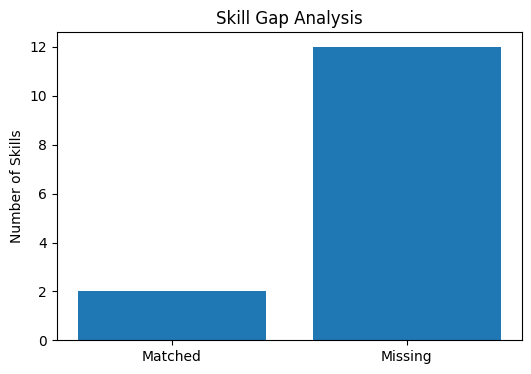

In [201]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.bar(
    ["Matched", "Missing"],
    [len(matched), len(missing)]
)

plt.title("Skill Gap Analysis")
plt.ylabel("Number of Skills")

plt.show()

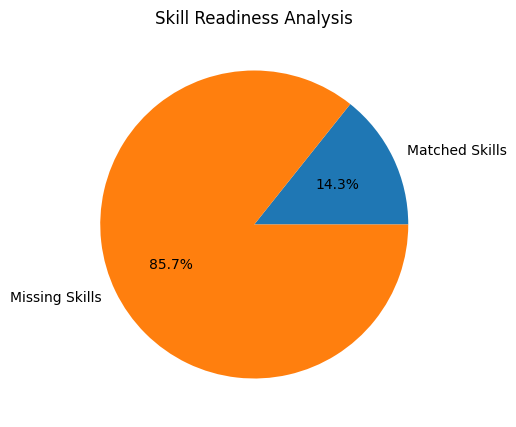

In [203]:
import matplotlib.pyplot as plt

labels = ["Matched Skills", "Missing Skills"]

values = [
    len(matched),
    len(missing)
]

plt.figure(figsize=(5,5))
plt.pie(
    values,
    labels=labels,
    autopct="%1.1f%%"
)

plt.title("Skill Readiness Analysis")

plt.show()

In [204]:
print("\nSUMMARY")

print("Matched Skills:", len(matched))
print("Missing Skills:", len(missing))
print("Total Required Skills:", len(required_skills))


SUMMARY
Matched Skills: 2
Missing Skills: 12
Total Required Skills: 14


In [205]:
!pip install gradio

In [208]:
def analyze(role, skills):

    my_skills = {
        skill.strip()
        for skill in skills.split(",")
    }

    try:
        score, matched, missing, required_skills = analyze_role(
            role,
            my_skills
        )

        result = f"""
🎯 TARGET ROLE: {role.title()}

📊 READINESS SCORE: {score}%

✅ MATCHED SKILLS:
{chr(10).join('✓ ' + skill for skill in sorted(matched))}

❌ MISSING SKILLS:
{chr(10).join('✗ ' + skill for skill in sorted(missing))}

📈 SUMMARY:
Matched Skills: {len(matched)}
Missing Skills: {len(missing)}
Total Required Skills: {len(required_skills)}

🗺️ 4-WEEK ROADMAP:
"""

        week = 1

        missing_list = sorted(list(missing))

        for i in range(0, len(missing_list), 2):

            result += f"\nWeek {week}:\n"

            for skill in missing_list[i:i+2]:
                result += f"• Learn {skill}\n"

            week += 1

        return result

    except Exception as e:
        return f"Error: {str(e)}"

In [211]:
import gradio as gr

demo = gr.Interface(
    fn=analyze,
    inputs=[
        gr.Textbox(label="Target Role"),
        gr.Textbox(label="Skills (comma separated)")
    ],
    outputs=gr.Textbox(
        label="Career Analysis",
        lines=30,
        max_lines=50
    ),
    title="🚀 SkillPath AI",
    description="RAG-Based Career Readiness Advisor"
)
demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9e74212fd2cb8e5074.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [212]:
!ls

IT_Job_Roles_Skills.csv  sample_data


In [213]:
%%writefile app.py

print("SkillPath AI")

Writing app.py


In [214]:
!ls

app.py	IT_Job_Roles_Skills.csv  sample_data


In [215]:
%%writefile requirements.txt

gradio
pandas
matplotlib
chromadb
sentence-transformers

Writing requirements.txt


In [216]:
%%writefile README.md

# SkillPath AI

RAG-Based Career Readiness Advisor

Features:
- Skill Gap Analysis
- Readiness Score
- Learning Roadmap
- Project Recommendations

Writing README.md


In [217]:
!ls

app.py	IT_Job_Roles_Skills.csv  README.md  requirements.txt  sample_data


In [218]:
print("SkillPath AI")

SkillPath AI


In [219]:
!cat app.py


print("SkillPath AI")


In [222]:
from google.colab import files
files.download('/content/job_skill.ipynb')

FileNotFoundError: Cannot find file: /content/job_skill.ipynb